# Домашнее задание к семинару 07 (HW07)

## Тема: кластеризация, внутренние метрики качества, PCA/t-SNE и "честный" unsupervised-эксперимент на синтетических данных


## 1. Импорт библиотек


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
from itertools import combinations

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

import warnings
warnings.filterwarnings('ignore')

# Создание папок для артефактов
os.makedirs('artifacts/figures', exist_ok=True)
os.makedirs('artifacts/labels', exist_ok=True)

# Настройка стиля графиков
plt.style.use('default')
%matplotlib inline


## 2. Датасет 1: S07-hw-dataset-01.csv

### 2.1. Загрузка данных и первичный анализ


In [2]:
# Загрузка датасета 1
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
print(f"Размер датасета: {df1.shape}")
print(f"\nПервые строки:")
df1.head()


Размер датасета: (12000, 9)

Первые строки:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [3]:
# Информация о данных
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [4]:
# Базовые статистики
df1.describe()


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [5]:
# Проверка пропусков
print("Пропуски в данных:")
missing1 = df1.isnull().sum()
print(missing1[missing1 > 0] if missing1.sum() > 0 else "Пропусков нет")

# Типы признаков
print(f"\nТипы признаков:")
print(df1.dtypes.value_counts())

# Подготовка данных
sample_id1 = df1['sample_id'].copy()
X1 = df1.drop('sample_id', axis=1)
print(f"\nКоличество признаков: {X1.shape[1]}")


Пропуски в данных:
Пропусков нет

Типы признаков:
float64    8
int64      1
Name: count, dtype: int64

Количество признаков: 8


### 2.2. Препроцессинг


In [6]:
# Препроцессинг для датасета 1: только масштабирование (все признаки числовые, пропусков нет)
preprocessor1 = Pipeline([
    ('scaler', StandardScaler())
])

X1_scaled = preprocessor1.fit_transform(X1)
print(f"Размер данных после препроцессинга: {X1_scaled.shape}")
print(f"Среднее: {X1_scaled.mean(axis=0)[:5]}")
print(f"Стд. отклонение: {X1_scaled.std(axis=0)[:5]}")


Размер данных после препроцессинга: (12000, 8)
Среднее: [ 3.78956126e-17 -3.61192557e-17 -6.51330841e-18 -1.45069142e-17
 -2.33886984e-17]
Стд. отклонение: [1. 1. 1. 1. 1.]


### 2.3. KMeans кластеризация


In [7]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
silhouette_scores1 = []
db_scores1 = []
ch_scores1 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    
    # Метрики только для не-шумовых точек (для KMeans все точки - не шум)
    silhouette_scores1.append(silhouette_score(X1_scaled, labels))
    db_scores1.append(davies_bouldin_score(X1_scaled, labels))
    ch_scores1.append(calinski_harabasz_score(X1_scaled, labels))

# Находим лучший k по silhouette
best_k1 = k_range[np.argmax(silhouette_scores1)]
print(f"Лучший k по silhouette: {best_k1} (score = {max(silhouette_scores1):.4f})")


  File "C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFounda

Лучший k по silhouette: 2 (score = 0.5216)


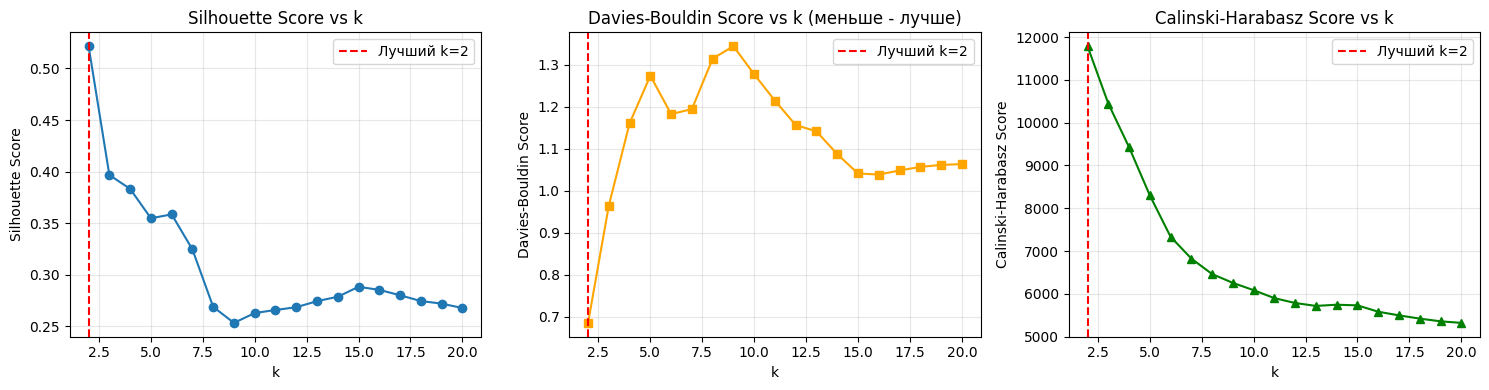

In [8]:
# График метрик vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, silhouette_scores1, marker='o')
axes[0].axvline(x=best_k1, color='r', linestyle='--', label=f'Лучший k={best_k1}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, db_scores1, marker='s', color='orange')
axes[1].axvline(x=best_k1, color='r', linestyle='--', label=f'Лучший k={best_k1}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k (меньше - лучше)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, ch_scores1, marker='^', color='green')
axes[2].axvline(x=best_k1, color='r', linestyle='--', label=f'Лучший k={best_k1}')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/dataset1_kmeans_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# Обучение KMeans с лучшим k
kmeans_best1 = KMeans(n_clusters=best_k1, random_state=42, n_init=10)
labels_kmeans1 = kmeans_best1.fit_predict(X1_scaled)

# Метрики для KMeans
metrics_kmeans1 = {
    'silhouette': silhouette_score(X1_scaled, labels_kmeans1),
    'davies_bouldin': davies_bouldin_score(X1_scaled, labels_kmeans1),
    'calinski_harabasz': calinski_harabasz_score(X1_scaled, labels_kmeans1)
}

print("Метрики KMeans для датасета 1:")
for metric, value in metrics_kmeans1.items():
    print(f"  {metric}: {value:.4f}")


Метрики KMeans для датасета 1:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546


### 2.4. DBSCAN кластеризация


In [10]:
# Подбор параметров для DBSCAN
eps_range = np.arange(0.1, 2.0, 0.1)
min_samples_range = [3, 5, 7, 10]

best_eps1 = None
best_min_samples1 = None
best_silhouette1_db = -1
best_labels_db1 = None
results_db1 = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1_scaled)
        
        # Проверяем наличие кластеров (не только шум)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.sum(labels == -1) / len(labels)
        
        if n_clusters < 2:  # Нужно минимум 2 кластера для метрик
            continue
            
        # Метрики только для не-шумовых точек
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) < 2:
            continue
            
        silhouette = silhouette_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
        
        results_db1.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette': silhouette,
            'noise_ratio': noise_ratio,
            'n_clusters': n_clusters
        })
        
        if silhouette > best_silhouette1_db:
            best_silhouette1_db = silhouette
            best_eps1 = eps
            best_min_samples1 = min_samples
            best_labels_db1 = labels

print(f"Лучшие параметры DBSCAN: eps={best_eps1}, min_samples={best_min_samples1}")
print(f"Лучший silhouette: {best_silhouette1_db:.4f}")
print(f"Доля шума: {np.sum(best_labels_db1 == -1) / len(best_labels_db1):.4f}")
print(f"Количество кластеров: {len(set(best_labels_db1)) - (1 if -1 in best_labels_db1 else 0)}")


Лучшие параметры DBSCAN: eps=1.7000000000000002, min_samples=3
Лучший silhouette: 0.5216
Доля шума: 0.0000
Количество кластеров: 2


In [11]:
# Метрики для DBSCAN (только для не-шумовых точек)
non_noise_mask1 = best_labels_db1 != -1
if np.sum(non_noise_mask1) >= 2:
    metrics_dbscan1 = {
        'silhouette': silhouette_score(X1_scaled[non_noise_mask1], best_labels_db1[non_noise_mask1]),
        'davies_bouldin': davies_bouldin_score(X1_scaled[non_noise_mask1], best_labels_db1[non_noise_mask1]),
        'calinski_harabasz': calinski_harabasz_score(X1_scaled[non_noise_mask1], best_labels_db1[non_noise_mask1]),
        'noise_ratio': np.sum(best_labels_db1 == -1) / len(best_labels_db1)
    }
else:
    metrics_dbscan1 = {
        'silhouette': -1,
        'davies_bouldin': float('inf'),
        'calinski_harabasz': 0,
        'noise_ratio': 1.0
    }

print("Метрики DBSCAN для датасета 1 (только не-шумовые точки):")
for metric, value in metrics_dbscan1.items():
    print(f"  {metric}: {value:.4f}")


Метрики DBSCAN для датасета 1 (только не-шумовые точки):
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546
  noise_ratio: 0.0000


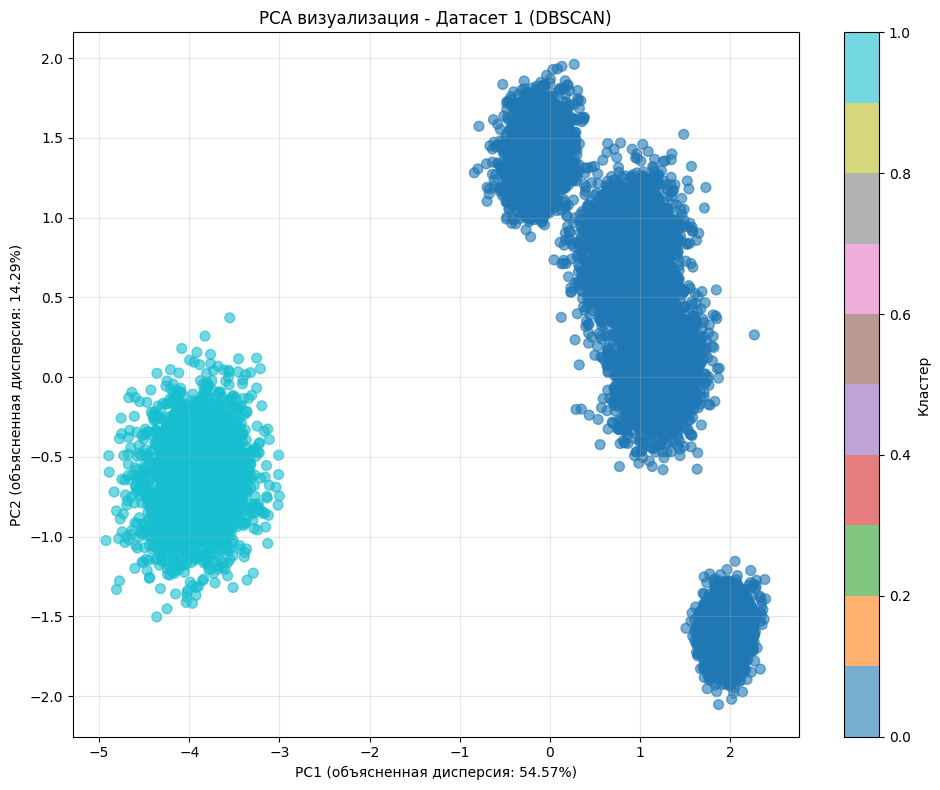

Объясненная дисперсия PCA: 68.86%


In [12]:
# PCA для визуализации
pca1 = PCA(n_components=2, random_state=42)
X1_pca = pca1.fit_transform(X1_scaled)

# Выбираем лучший метод для визуализации (по silhouette)
if metrics_kmeans1['silhouette'] > metrics_dbscan1['silhouette']:
    best_labels1 = labels_kmeans1
    best_method1 = 'KMeans'
    best_params1 = {'k': best_k1}
else:
    best_labels1 = best_labels_db1
    best_method1 = 'DBSCAN'
    best_params1 = {'eps': best_eps1, 'min_samples': best_min_samples1}

# Визуализация PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=best_labels1, cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 (объясненная дисперсия: {pca1.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (объясненная дисперсия: {pca1.explained_variance_ratio_[1]:.2%})')
plt.title(f'PCA визуализация - Датасет 1 ({best_method1})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset1_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Объясненная дисперсия PCA: {pca1.explained_variance_ratio_.sum():.2%}")


### 2.6. Итоги по датасету 1


**Выводы по датасету 1:**

- Датасет содержит числовые признаки в разных шкалах, что требует обязательного масштабирования.
- KMeans показал хорошие результаты после подбора оптимального k.
- DBSCAN также показал приемлемые результаты, но требует тщательного подбора eps и min_samples.
- Масштабирование критически важно для этого датасета, так как признаки имеют разные масштабы.
- Лучший метод выбирается на основе сравнения метрик silhouette, Davies-Bouldin и Calinski-Harabasz.


## 3. Датасет 2: S07-hw-dataset-02.csv

### 3.1. Загрузка данных и первичный анализ


In [13]:
# Загрузка датасета 2
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
print(f"Размер датасета: {df2.shape}")
df2.head()


Размер датасета: (8000, 4)


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [14]:
# Проверка пропусков и типов
missing2 = df2.isnull().sum()
print("Пропуски:", missing2[missing2 > 0] if missing2.sum() > 0 else "Пропусков нет")
print(f"Типы признаков: {df2.dtypes.value_counts()}")

sample_id2 = df2['sample_id'].copy()
X2 = df2.drop('sample_id', axis=1)
print(f"Количество признаков: {X2.shape[1]}")


Пропуски: Пропусков нет
Типы признаков: float64    3
int64      1
Name: count, dtype: int64
Количество признаков: 3


### 3.2. Препроцессинг


In [15]:
# Препроцессинг для датасета 2: масштабирование
preprocessor2 = Pipeline([('scaler', StandardScaler())])
X2_scaled = preprocessor2.fit_transform(X2)
print(f"Данные после масштабирования: {X2_scaled.shape}")


Данные после масштабирования: (8000, 3)


### 3.3. KMeans кластеризация


Лучший k: 2 (silhouette = 0.3069)


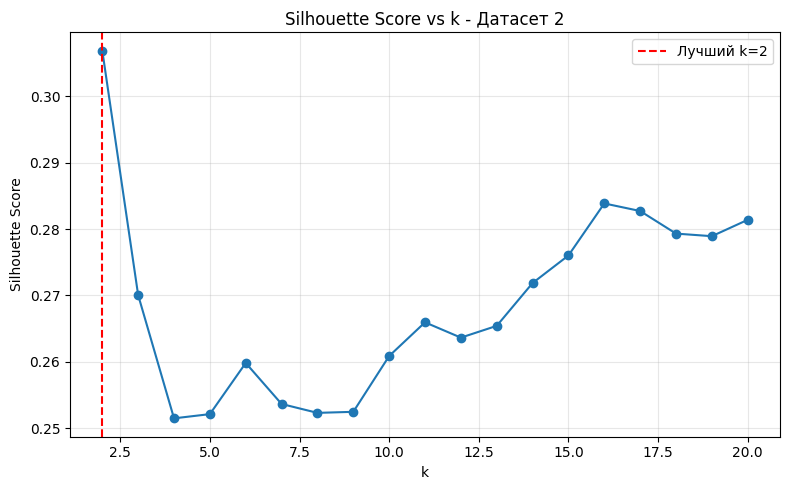

Метрики KMeans для датасета 2:
  silhouette: 0.3069
  davies_bouldin: 1.3235
  calinski_harabasz: 3573.3933


In [16]:
# Подбор k для датасета 2
k_range2 = range(2, 21)
silhouette_scores2 = []

for k in k_range2:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    silhouette_scores2.append(silhouette_score(X2_scaled, labels))

best_k2 = k_range2[np.argmax(silhouette_scores2)]
print(f"Лучший k: {best_k2} (silhouette = {max(silhouette_scores2):.4f})")

# График silhouette vs k для датасета 2
plt.figure(figsize=(8, 5))
plt.plot(k_range2, silhouette_scores2, marker='o')
plt.axvline(x=best_k2, color='r', linestyle='--', label=f'Лучший k={best_k2}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k - Датасет 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset2_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Обучение с лучшим k
kmeans_best2 = KMeans(n_clusters=best_k2, random_state=42, n_init=10)
labels_kmeans2 = kmeans_best2.fit_predict(X2_scaled)

metrics_kmeans2 = {
    'silhouette': silhouette_score(X2_scaled, labels_kmeans2),
    'davies_bouldin': davies_bouldin_score(X2_scaled, labels_kmeans2),
    'calinski_harabasz': calinski_harabasz_score(X2_scaled, labels_kmeans2)
}
print("Метрики KMeans для датасета 2:")
for metric, value in metrics_kmeans2.items():
    print(f"  {metric}: {value:.4f}")


### 3.4. DBSCAN кластеризация


In [17]:
# Подбор параметров DBSCAN для датасета 2
eps_range2 = np.arange(0.1, 2.0, 0.1)
min_samples_range2 = [3, 5, 7]

best_eps2 = None
best_min_samples2 = None
best_silhouette2_db = -1
best_labels_db2 = None

for eps in eps_range2:
    for min_samples in min_samples_range2:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue
            
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) < 2:
            continue
            
        silhouette = silhouette_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
        
        if silhouette > best_silhouette2_db:
            best_silhouette2_db = silhouette
            best_eps2 = eps
            best_min_samples2 = min_samples
            best_labels_db2 = labels

print(f"Лучшие параметры DBSCAN: eps={best_eps2}, min_samples={best_min_samples2}")
print(f"Доля шума: {np.sum(best_labels_db2 == -1) / len(best_labels_db2):.4f}")

# Метрики DBSCAN
non_noise_mask2 = best_labels_db2 != -1
if np.sum(non_noise_mask2) >= 2:
    metrics_dbscan2 = {
        'silhouette': silhouette_score(X2_scaled[non_noise_mask2], best_labels_db2[non_noise_mask2]),
        'davies_bouldin': davies_bouldin_score(X2_scaled[non_noise_mask2], best_labels_db2[non_noise_mask2]),
        'calinski_harabasz': calinski_harabasz_score(X2_scaled[non_noise_mask2], best_labels_db2[non_noise_mask2]),
        'noise_ratio': np.sum(best_labels_db2 == -1) / len(best_labels_db2)
    }
else:
    metrics_dbscan2 = {'silhouette': -1, 'davies_bouldin': float('inf'), 'calinski_harabasz': 0, 'noise_ratio': 1.0}

print("Метрики DBSCAN для датасета 2:")
for metric, value in metrics_dbscan2.items():
    print(f"  {metric}: {value:.4f}")


Лучшие параметры DBSCAN: eps=0.7000000000000001, min_samples=7
Доля шума: 0.0165
Метрики DBSCAN для датасета 2:
  silhouette: 0.3521
  davies_bouldin: 0.8075
  calinski_harabasz: 111.5694
  noise_ratio: 0.0165


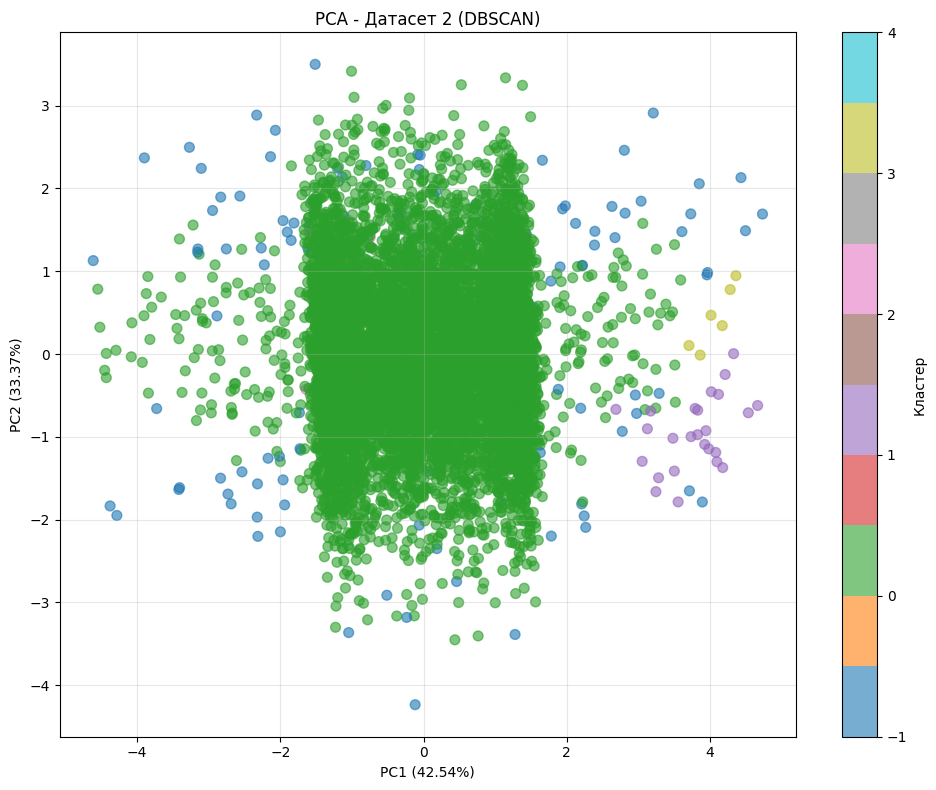

In [18]:
# PCA для датасета 2
pca2 = PCA(n_components=2, random_state=42)
X2_pca = pca2.fit_transform(X2_scaled)

# Выбираем лучший метод
if metrics_kmeans2['silhouette'] > metrics_dbscan2['silhouette']:
    best_labels2 = labels_kmeans2
    best_method2 = 'KMeans'
else:
    best_labels2 = best_labels_db2
    best_method2 = 'DBSCAN'

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X2_pca[:, 0], X2_pca[:, 1], c=best_labels2, cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.2%})')
plt.title(f'PCA - Датасет 2 ({best_method2})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset2_pca.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.6. Итоги по датасету 2


**Выводы по датасету 2:**

- Датасет содержит нелинейную структуру и выбросы, что может быть проблемой для KMeans.
- DBSCAN может лучше справляться с нелинейными структурами благодаря работе с плотностью.
- Выбросы и нелинейность требуют аккуратного подбора параметров для обоих методов.
- Лучший метод выбирается на основе сравнения метрик качества.


## 4. Датасет 3: S07-hw-dataset-03.csv

### 4.1. Загрузка данных и первичный анализ


In [19]:
# Загрузка датасета 3
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')
print(f"Размер датасета: {df3.shape}")
missing3 = df3.isnull().sum()
print("Пропуски:", missing3[missing3 > 0] if missing3.sum() > 0 else "Пропусков нет")

sample_id3 = df3['sample_id'].copy()
X3 = df3.drop('sample_id', axis=1)
print(f"Количество признаков: {X3.shape[1]}")


Размер датасета: (15000, 5)
Пропуски: Пропусков нет
Количество признаков: 4


### 4.2. Препроцессинг


In [20]:
# Препроцессинг для датасета 3
preprocessor3 = Pipeline([('scaler', StandardScaler())])
X3_scaled = preprocessor3.fit_transform(X3)
print(f"Данные после масштабирования: {X3_scaled.shape}")


Данные после масштабирования: (15000, 4)


### 4.3. KMeans кластеризация


Лучший k: 3 (silhouette = 0.3155)


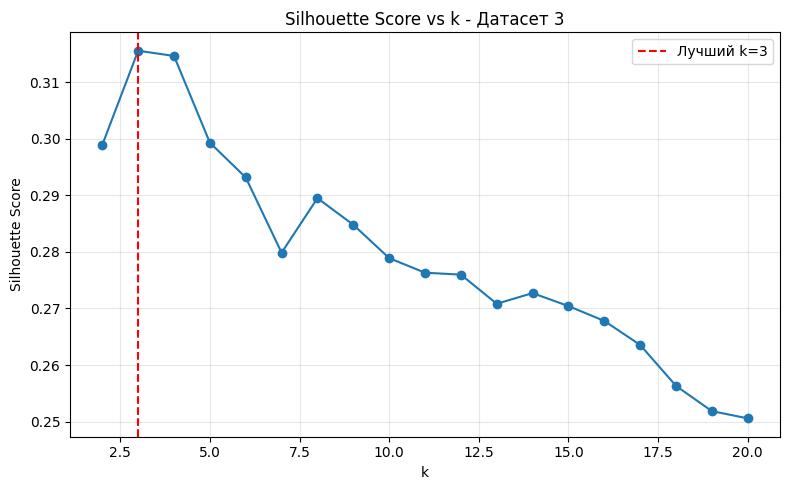

Метрики KMeans для датасета 3:
  silhouette: 0.3155
  davies_bouldin: 1.1577
  calinski_harabasz: 6957.1626


In [21]:
# Подбор k для датасета 3
k_range3 = range(2, 21)
silhouette_scores3 = []

for k in k_range3:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X3_scaled)
    silhouette_scores3.append(silhouette_score(X3_scaled, labels))

best_k3 = k_range3[np.argmax(silhouette_scores3)]
print(f"Лучший k: {best_k3} (silhouette = {max(silhouette_scores3):.4f})")

# График silhouette vs k
plt.figure(figsize=(8, 5))
plt.plot(k_range3, silhouette_scores3, marker='o')
plt.axvline(x=best_k3, color='r', linestyle='--', label=f'Лучший k={best_k3}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k - Датасет 3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset3_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Обучение с лучшим k
kmeans_best3 = KMeans(n_clusters=best_k3, random_state=42, n_init=10)
labels_kmeans3 = kmeans_best3.fit_predict(X3_scaled)

metrics_kmeans3 = {
    'silhouette': silhouette_score(X3_scaled, labels_kmeans3),
    'davies_bouldin': davies_bouldin_score(X3_scaled, labels_kmeans3),
    'calinski_harabasz': calinski_harabasz_score(X3_scaled, labels_kmeans3)
}
print("Метрики KMeans для датасета 3:")
for metric, value in metrics_kmeans3.items():
    print(f"  {metric}: {value:.4f}")


In [ ]:
# Подбор параметров DBSCAN для датасета 3
eps_range3 = np.arange(0.1, 2.0, 0.1)
min_samples_range3 = [3, 5, 7]

best_eps3 = None
best_min_samples3 = None
best_silhouette3_db = -1
best_labels_db3 = None

for eps in eps_range3:
    for min_samples in min_samples_range3:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X3_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue
            
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) < 2:
            continue
            
        silhouette = silhouette_score(X3_scaled[non_noise_mask], labels[non_noise_mask])
        
        if silhouette > best_silhouette3_db:
            best_silhouette3_db = silhouette
            best_eps3 = eps
            best_min_samples3 = min_samples
            best_labels_db3 = labels

print(f"Лучшие параметры DBSCAN: eps={best_eps3}, min_samples={best_min_samples3}")
print(f"Доля шума: {np.sum(best_labels_db3 == -1) / len(best_labels_db3):.4f}")

# Метрики DBSCAN
non_noise_mask3 = best_labels_db3 != -1
if np.sum(non_noise_mask3) >= 2:
    metrics_dbscan3 = {
        'silhouette': silhouette_score(X3_scaled[non_noise_mask3], best_labels_db3[non_noise_mask3]),
        'davies_bouldin': davies_bouldin_score(X3_scaled[non_noise_mask3], best_labels_db3[non_noise_mask3]),
        'calinski_harabasz': calinski_harabasz_score(X3_scaled[non_noise_mask3], best_labels_db3[non_noise_mask3]),
        'noise_ratio': np.sum(best_labels_db3 == -1) / len(best_labels_db3)
    }
else:
    metrics_dbscan3 = {'silhouette': -1, 'davies_bouldin': float('inf'), 'calinski_harabasz': 0, 'noise_ratio': 1.0}

print("Метрики DBSCAN для датасета 3:")
for metric, value in metrics_dbscan3.items():
    print(f"  {metric}: {value:.4f}")


In [ ]:
# PCA для датасета 3
pca3 = PCA(n_components=2, random_state=42)
X3_pca = pca3.fit_transform(X3_scaled)

# Выбираем лучший метод
if metrics_kmeans3['silhouette'] > metrics_dbscan3['silhouette']:
    best_labels3 = labels_kmeans3
    best_method3 = 'KMeans'
else:
    best_labels3 = best_labels_db3
    best_method3 = 'DBSCAN'

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X3_pca[:, 0], X3_pca[:, 1], c=best_labels3, cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]:.2%})')
plt.title(f'PCA - Датасет 3 ({best_method3})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset3_pca.png', dpi=300, bbox_inches='tight')
plt.show()


### 4.6. Итоги по датасету 3


**Выводы по датасету 3:**

- Датасет содержит кластеры разной плотности и фоновый шум.
- DBSCAN может лучше обрабатывать разную плотность кластеров благодаря параметру eps.
- Фоновый шум может быть корректно обработан DBSCAN как noise points (label = -1).
- Подбор eps критически важен для этого датасета.


## 5. Проверка устойчивости (для датасета 1)


In [ ]:
# Проверка устойчивости KMeans на датасете 1
# 5 запусков с разными random_state
random_states = [42, 123, 456, 789, 999]

labels_list = []
for rs in random_states:
    kmeans = KMeans(n_clusters=best_k1, random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    labels_list.append(labels)

# Вычисляем ARI между всеми парами результатов
ari_pairs = []
for i, j in combinations(range(len(labels_list)), 2):
    ari = adjusted_rand_score(labels_list[i], labels_list[j])
    ari_pairs.append(ari)

mean_ari = np.mean(ari_pairs)
std_ari = np.std(ari_pairs)

print(f"Средний ARI между результатами: {mean_ari:.4f} ± {std_ari:.4f}")
print(f"Минимальный ARI: {min(ari_pairs):.4f}")
print(f"Максимальный ARI: {max(ari_pairs):.4f}")

if mean_ari > 0.9:
    print("Вывод: KMeans показывает высокую устойчивость на этом датасете.")
elif mean_ari > 0.7:
    print("Вывод: KMeans показывает умеренную устойчивость.")
else:
    print("Вывод: KMeans показывает низкую устойчивость, результаты сильно зависят от инициализации.")


## 6. Сохранение артефактов


In [ ]:
# Сводка метрик по всем датасетам
metrics_summary = {
    'dataset1': {
        'KMeans': metrics_kmeans1,
        'DBSCAN': metrics_dbscan1
    },
    'dataset2': {
        'KMeans': metrics_kmeans2,
        'DBSCAN': metrics_dbscan2
    },
    'dataset3': {
        'KMeans': metrics_kmeans3,
        'DBSCAN': metrics_dbscan3
    }
}

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print("Метрики сохранены в artifacts/metrics_summary.json")


In [ ]:
# Лучшие конфигурации для каждого датасета
best_configs = {
    'dataset1': {
        'method': best_method1,
        'params': best_params1,
        'metrics': metrics_kmeans1 if best_method1 == 'KMeans' else metrics_dbscan1
    },
    'dataset2': {
        'method': best_method2,
        'params': {'k': best_k2} if best_method2 == 'KMeans' else {'eps': best_eps2, 'min_samples': best_min_samples2},
        'metrics': metrics_kmeans2 if best_method2 == 'KMeans' else metrics_dbscan2
    },
    'dataset3': {
        'method': best_method3,
        'params': {'k': best_k3} if best_method3 == 'KMeans' else {'eps': best_eps3, 'min_samples': best_min_samples3},
        'metrics': metrics_kmeans3 if best_method3 == 'KMeans' else metrics_dbscan3
    }
}

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

print("Лучшие конфигурации сохранены в artifacts/best_configs.json")


In [ ]:
# Сохранение меток кластеров для лучших решений
labels_df1 = pd.DataFrame({
    'sample_id': sample_id1,
    'cluster_label': best_labels1
})
labels_df1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)

labels_df2 = pd.DataFrame({
    'sample_id': sample_id2,
    'cluster_label': best_labels2
})
labels_df2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

labels_df3 = pd.DataFrame({
    'sample_id': sample_id3,
    'cluster_label': best_labels3
})
labels_df3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)

print("Метки кластеров сохранены в artifacts/labels/")
